---
title: "ColormaNN manuscript figures - PanUKB T2D - NNM Sparse"
author: "Saikat Banerjee"
format:
  html: default
date: "2025-04-10"
file-modified: "2025-04-10"
abstract: "High quality plots used for PanUKB type 2 diabetes (NNM Sparse model), using NYGC color palette."

---

In [1]:
import numpy as np
import pandas as pd
import pickle
import sys
import os
import re
from collections import defaultdict

_lr_pat = re.compile(r"\s*\((left|right)\)\s*$", flags=re.IGNORECASE)

import matplotlib
import matplotlib.pyplot as plt
from pymir import mpl_stylesheet
from pymir import mpl_utils

import scipy.stats as sc_stats
import collections
import textalloc
from adjustText import adjust_text

# For OpenTargets API
import requests
import json

In [28]:
# import matplotlib.font_manager as mpl_fm
# font_path = '/gpfs/commons/home/sbanerjee/nygc/Futura'
# mpl_fm.fontManager.addfont(font_path + '/FuturaStd-Book.otf') # Loads "Futura Std"

# mpl_stylesheet.banskt_presentation(splinecolor = 'black', dpi = 300)
# futura_book = FontProperties(fname='/gpfs/commons/home/sbanerjee/nygc/Futura/FuturaStd-Book.otf')

import matplotlib.font_manager as mpl_fm
font_path = '/gpfs/commons/home/sbanerjee/nygc/Boehringer_Forward_Latin_Cycrillic_Greek/Text'
mpl_fm.fontManager.addfont(font_path + '/BoehringerForwardText.ttf') # Loads "Boehringer Forward Text"

# mpl_stylesheet.banskt_presentation(splinecolor = 'black', dpi = 300)
# boehringer_font = FontProperties(fname='/gpfs/commons/home/sbanerjee/nygc/Boehringer_Forward_Latin_Cycrillic_Greek/Text/BoehringerForwardText.ttf')

# NYGC Color Palette
nygc_colors = {
    'brown': '#7F0814',
    'darkred': '#d42e12',
    'orange': '#F37239',
    'darkyellow': '#F79320',
    'yellow': '#FFE438',
    'darkblue': '#003059',
    'blue': '#266DB6',
    'lightblue': '#A3D5ED',
    'darkgreen': '#006838',
    'green': '#0A8A42',
    'lightgreen': '#74B74A',
    'yellowgreen': '#BAD75F',
    'darkgray': '#1A1A1A',
    'gray': '#666666',
    'lightgray': '#CCCCCC',
    'khaki': '#ADA194',
    'darkkhaki': '#5E514D',
}

manuscript_colors = {
    'brown': '#7F180D',
    'darkred': '#C10020',
    'darkyellow': '#FF6800',
    'blue': '#00538A',
    'green': '#0A8A42',
    'lightgreen': '#74B74A',    
    'yellowgreen': '#93AA00',
    'lightblue': '#A6BDD7',
    'purple': '#803E75',
    'olive': '#232C16',
    'khaki': '#CEA262',
    'orange': '#F37239',
    'gray': '#666666',
    'darkgray': '#1A1A1A',
    'lightgray': '#CCCCCC',
}

boehringer_colors = {
    'darkgreen' : '#08312A',
    'accentgreen': '#00E47C',
    'warmgray': '#E5E3DE',
    'lightgray': '#F6F5F3',
    'lightyellow': '#fbf9aa',
    'yellow': '#ffe667',
    'mediumyellow': '#ffd03d',
    'mediumred': '#ee6541',
    'mediumblue': '#6ad2e2',
    'lightviolet': '#e0e1f6',
    'violet': '#c5c3ee',
    'mediumviolet': '#928bde',
}
    

# # Style sheet for manuscript
# mpl_stylesheet.banskt_presentation(dpi = 300, fontsize = 22, 
#     splinecolor = manuscript_colors['darkgray'], black = manuscript_colors['darkgray'])

# Style sheet for Boehringer
mpl_stylesheet.banskt_presentation(dpi = 300, fontsize = 22, 
    splinecolor = boehringer_colors['darkgreen'], black = boehringer_colors['darkgreen'])
plt.rcParams['font.family'] = 'Boehringer Forward Text'

In [4]:
def iqr_outlier(x, axis = None, bar = 1.5, side = 'both'):
    assert side in ['gt', 'lt', 'both'], 'Side should be `gt`, `lt` or `both`.'
    
    def q1(x, axis = None):
        return np.percentile(x, 25, axis = axis)

    def q3(x, axis = None):
        return np.percentile(x, 75, axis = axis)

    d_iqr = sc_stats.iqr(x, axis = axis)
    d_q1 = q1(x, axis = axis)
    d_q3 = q3(x, axis = axis)
    iqr_distance = np.multiply(d_iqr, bar)

    stat_shape = list(x.shape)

    if isinstance(axis, collections.abc.Iterable):
        for single_axis in axis:
            stat_shape[single_axis] = 1
    else:
        stat_shape[axis] = 1

    if side in ['gt', 'both']:
        upper_range = d_q3 + iqr_distance
        upper_outlier = np.greater(x - upper_range.reshape(stat_shape), 0)
    if side in ['lt', 'both']:
        lower_range = d_q1 - iqr_distance
        lower_outlier = np.less(x - lower_range.reshape(stat_shape), 0)

    if side == 'gt':
        return upper_outlier
    if side == 'lt':
        return lower_outlier
    if side == 'both':
        return np.logical_or(upper_outlier, lower_outlier)

In [5]:
data_dir = "/gpfs/commons/home/sbanerjee/work/npd/PanUKB/data"
result_dir = "/gpfs/commons/home/sbanerjee/npddata/panukb/results/colormann-svd"

zscore_df = pd.read_pickle(os.path.join(data_dir, f"modselect/zscore_noRx.pkl"))
trait_df  = pd.read_pickle(os.path.join(data_dir, f"modselect/traits_all_with_desc.pkl"))

variant_filename = f"{data_dir}/allvar.pruned.closesttss.hugo"
variant_df = pd.read_csv(variant_filename, sep = '\t')

nsample_filename = "/gpfs/commons/home/sbanerjee/work/npd/PanUKB/data/phe2483.SampleN.tsv"
nsample_df = pd.read_csv(nsample_filename, sep = '\t')

In [6]:
methods = ["nnm", "nnm-sparse", "rpca"]
method_names = {
    "nnm" : "NNM",
    "nnm-sparse" : "NNM-Sparse",
    "rpca" : "Robust PCA"
}

res_pklfile = {
    "nnm": "nnm_model_r155872_iter1000.pkl",
    "nnm-sparse": "nnm_sparse_model_r155872_iter1000.pkl",
    "rpca": "rpca_model.pkl"
}

pca_comps = dict()
mf_comps = dict()
k = 200

for method in methods:
    comps_filename = os.path.join(result_dir, method, "noRx", "pca_comps.pkl")
    with open(comps_filename, "rb") as mfile:
        pca_comps[method] = pickle.load(mfile)
    mf_comps_filename = os.path.join(result_dir, method, "noRx", f"mf_comps_k{k}.pkl")
    with open(mf_comps_filename, "rb") as mfile:
        mf_comps[method] = pickle.load(mfile)
        
X = np.array(zscore_df.values.T)
X_cent = X - np.mean(X, axis = 0, keepdims = True)

In [7]:
pheno_zindex = [int(x[1:]) for x in zscore_df.columns]
trait_df_noRx = trait_df.loc[trait_df['zindex'].isin(pheno_zindex)]
nsample_df_noRx = nsample_df.loc[trait_df_noRx.index]
trait_df_noRx.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2110 entries, 0 to 2482
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   zindex                       2110 non-null   int64  
 1   trait_type                   2110 non-null   object 
 2   phenocode                    2110 non-null   object 
 3   pheno_sex                    2110 non-null   object 
 4   coding                       267 non-null    object 
 5   modifier                     394 non-null    object 
 6   description                  2110 non-null   object 
 7   description_more             1408 non-null   object 
 8   coding_description           261 non-null    object 
 9   category                     2072 non-null   object 
 10  BIN_QT                       2110 non-null   object 
 11  n_cases_EUR                  2110 non-null   int64  
 12  n_controls_EUR               1304 non-null   float64
 13  N                      

In [8]:
# focal_disease = {
#     "opentarget_name" : "type 1 diabetes mellitus",
#     "opentarget_id": "MONDO_0005147",
#     "df_query_string": "Type 1 diabetes",
# }

focal_disease = {
    "opentarget_name" : "type 2 diabetes mellitus",
    "opentarget_id": "MONDO_0005148",
    "df_query_string": "Type 2 diabetes",
}

trait_df_noRx.query(f"description == '{focal_disease['df_query_string']}'")

,zindex,trait_type,phenocode,pheno_sex,coding,modifier,description,description_more,coding_description,category,BIN_QT,n_cases_EUR,n_controls_EUR,N,Neff,filename,aws_link,estimates.final.h2_observed,long_description,short_description
459,460,phecode,250.2,both_sexes,NaN,NaN,Type 2 diabetes,NaN,NaN,endocrine/metabolic,BIN,22768,396181.0,418949,43061.32254,phecode-250.2-both_sexes.tsv.bgz,https://pan-ukb-us-east-1.s3.amazonaws.com/sum...,0.0484,Type 2 diabetes,Type 2 diabetes


In [9]:
zindex = trait_df_noRx.query(f"description == '{focal_disease['df_query_string']}'")["zindex"].values[0]
method = "nnm-sparse"

trait_indices = np.array(trait_df_noRx.index)
tidx = np.searchsorted(trait_indices, zindex - 1)

loadings, factors, cos2_pheno, cos2_variant, contribution_pheno, contribution_variant = mf_comps[method]

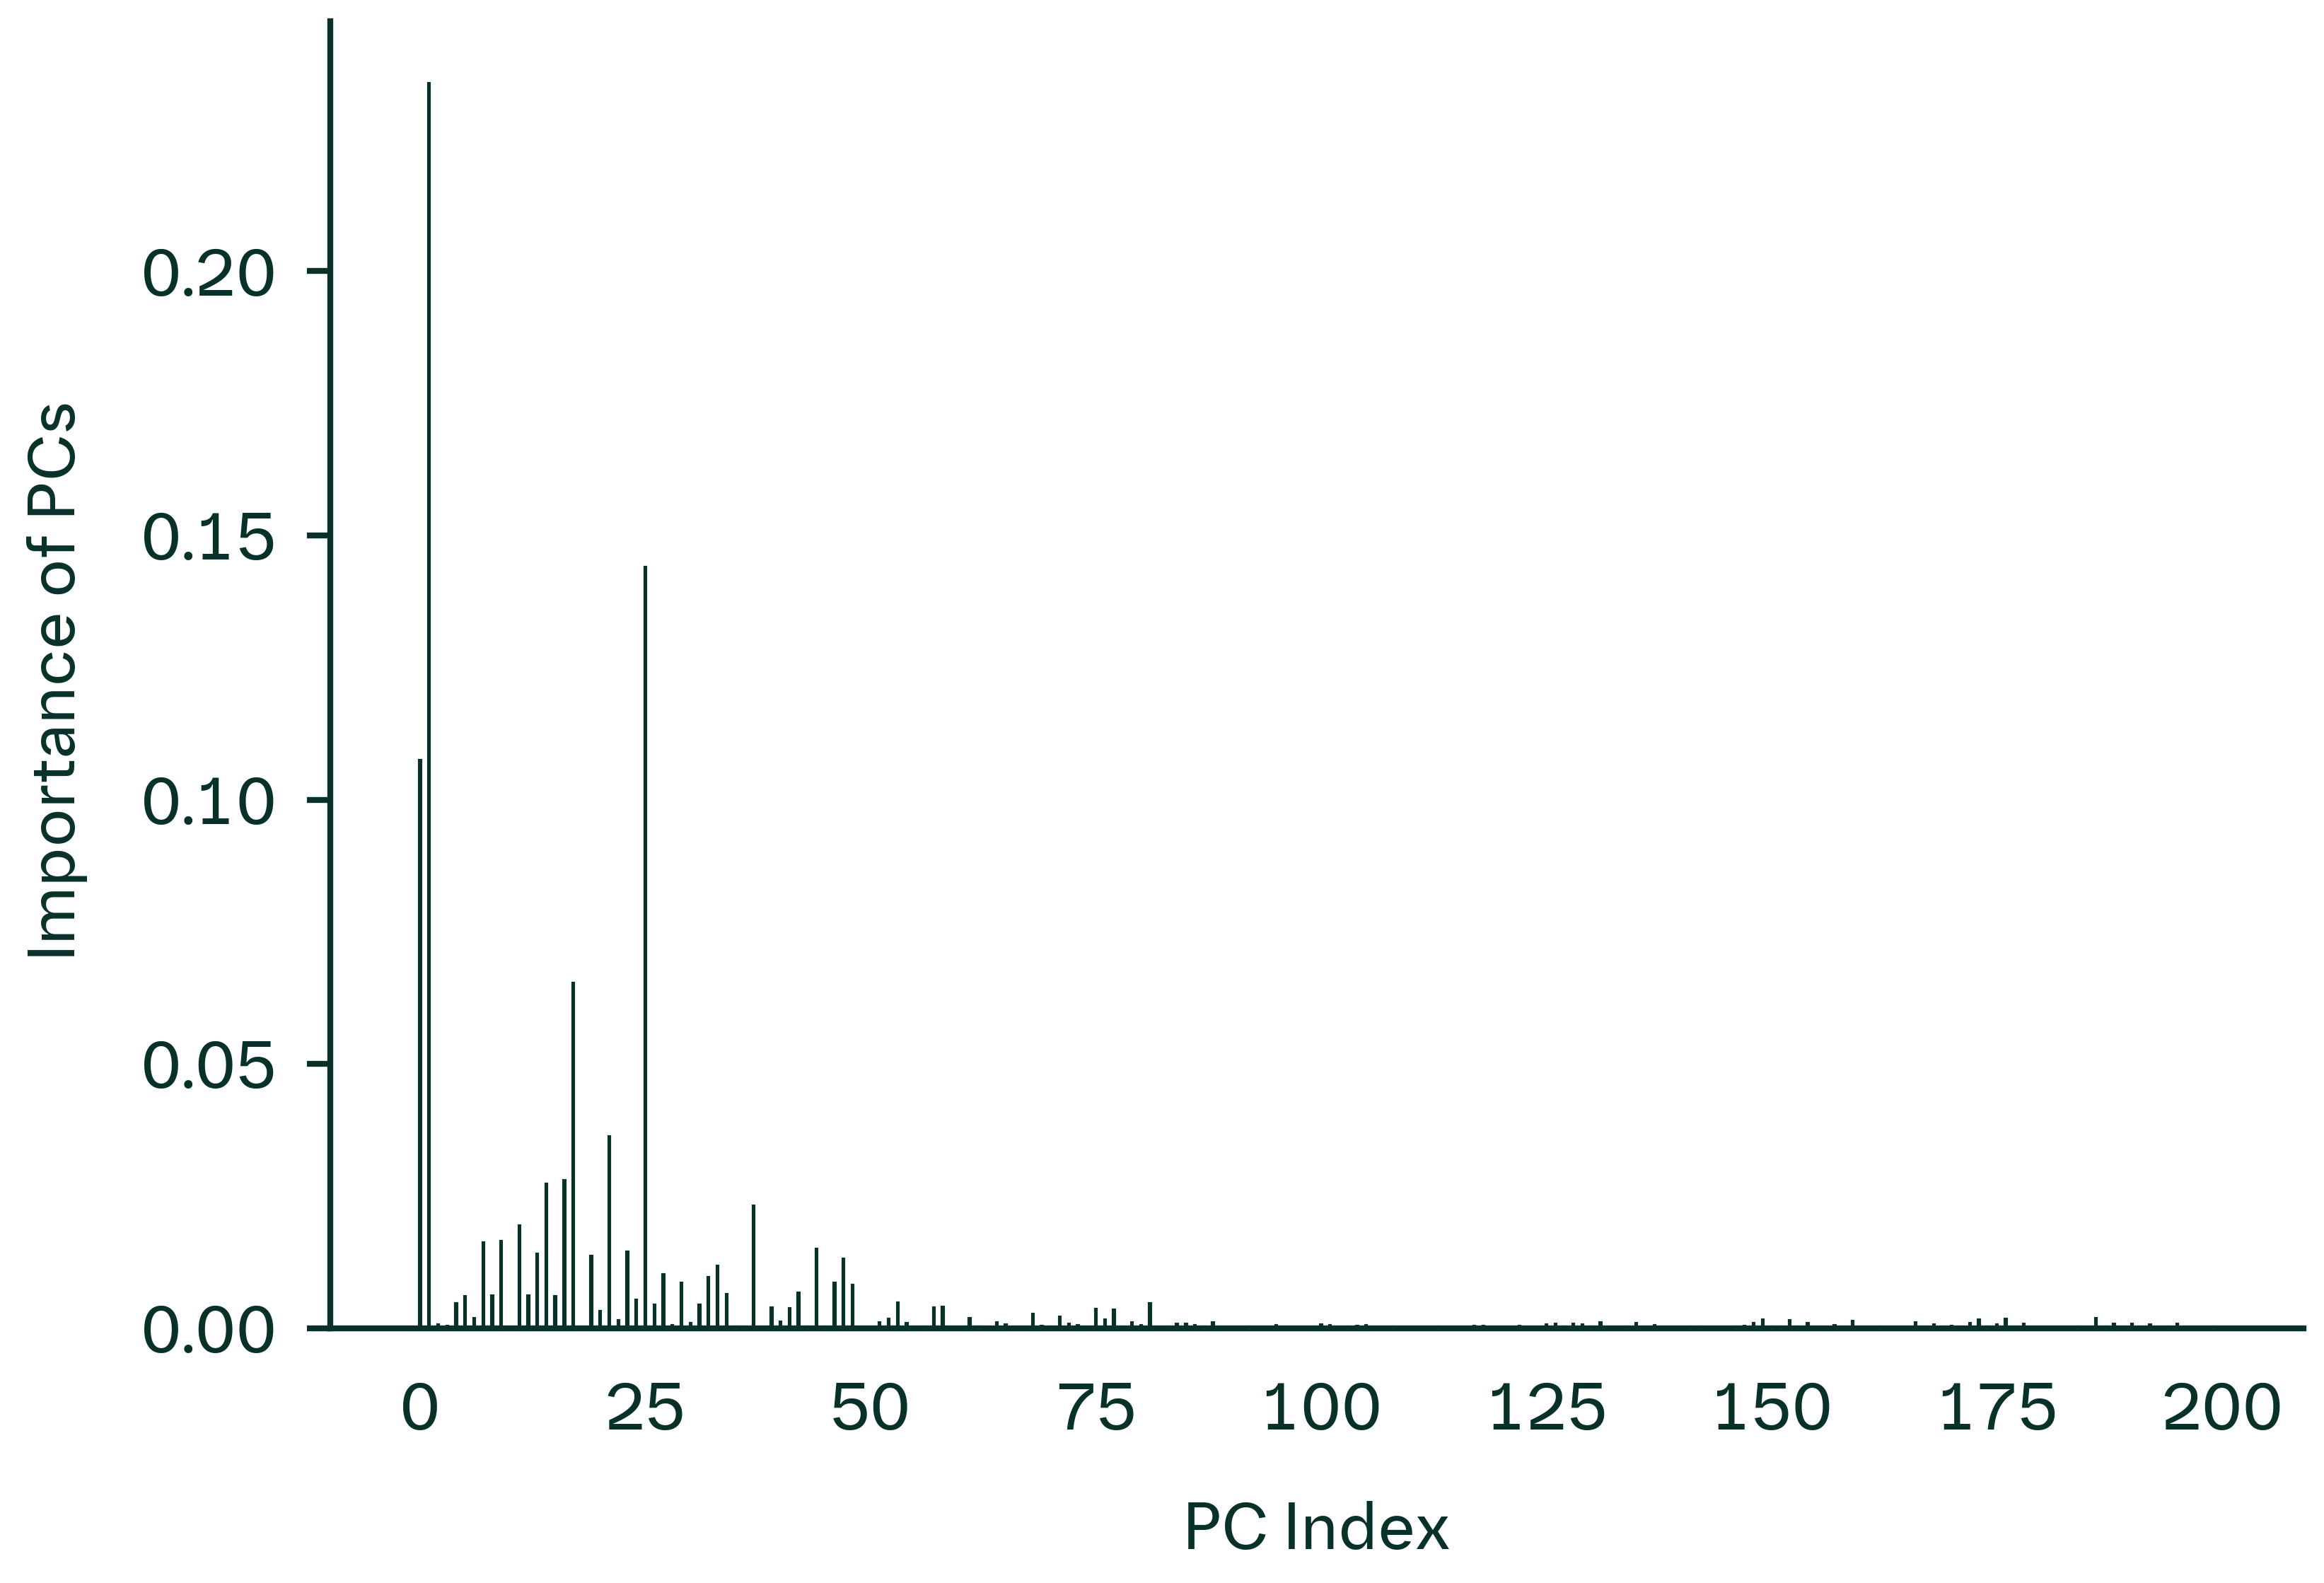

In [12]:
fig = plt.figure(figsize = (12, 8))
ax1 = fig.add_subplot(111)

xvals = np.arange(cos2_pheno[tidx,:].shape[0])
yvals = cos2_pheno[tidx,:]
ax1.bar(xvals, yvals, align = 'center', width = 0.1)

for side in ['top', 'right']:
    ax1.spines[side].set_visible(False)
    
ax1.tick_params(bottom=False)
ax1.set_ylabel(f"Importance of PCs")
ax1.set_xlabel(f"PC Index")

plt.show()

In [13]:
np.argsort(cos2_pheno[tidx,:])[::-1]

array([  1,  25,   0,  17,  21,  16,  14,  37,  11,   9,   7,  44,  23,
        13,  19,  47,  33,  27,  32,  29,  46,  48,  42,  34,  12,   8,
        15,   5,  24,  53,   4,  81,  26,  31,  58,  39,  57,  41,  75,
        77,  20,  68,  71, 186,   6,  61,  52, 176, 149,  76, 173,  22,
       152, 159,  40,  64, 131, 166,  88,  79,  51, 154, 135,  30, 172,
       148,  54, 195,  72, 126, 178, 128,  85, 188,  84, 190, 125,  65,
       192, 175, 129, 100, 168,   2, 105,  80,  95,  73,  28,  86, 137,
       157, 101,   3, 104,  69, 170, 122, 118, 147, 117, 150, 146,  45,
       127, 108, 187, 153,  36,  70, 142,  56, 162,  35,  92, 194,  83,
       184,  62, 103,  43, 151, 113, 141, 130, 199,  87, 134, 174, 136,
        82,  98,  59, 179, 112, 189,  67, 106,  50, 169, 160,  96, 165,
       161, 139, 124, 114,  99,  74, 185,  89,  91, 198, 140, 156, 120,
        94, 102,  49, 171, 180,  63, 145, 107,  10, 109,  60, 133, 167,
       111, 115,  55,  18, 123,  93, 164, 183, 193, 110, 191,  7

In [14]:
def get_opentarget_score(gene_id):

    # Build query string to get association information
    query_string = """
        query TargetAssociationsQuery(
          $ensemblId: String!
          $filter: String
          $sortBy: String!
          $enableIndirect: Boolean!
        ) {
          target(ensemblId: $ensemblId) {
            id
            approvedSymbol
            associatedDiseases(
              orderByScore: $sortBy
              BFilter: $filter
              enableIndirect: $enableIndirect
            ) {
              count
              rows {
                disease {
                  id
                  name
                }
                score
              }
            }
          }
        }

    """

    # Set variables object of arguments to be passed to endpoint
    variables = {
        "ensemblId": gene_id, 
        "filter": focal_disease["opentarget_name"],
        "sortBy": "score",
        "enableIndirect": False
    }

    # Set base URL of GraphQL API endpoint
    base_url = "https://api.platform.opentargets.org/api/v4/graphql"
    # print (gene_id)

    # Perform POST request and check status code of response
    r = requests.post(base_url, json={"query": query_string, "variables": variables})
    # print(r.status_code)

    # Transform API response from JSON into Python dictionary and print in console
    api_response = json.loads(r.text)
    # print(api_response)

    score = 0.0
    if api_response['data']['target'] is not None:
        associated_diseases = api_response['data']['target']['associatedDiseases']['rows']
        for d in associated_diseases:
            if d['disease']['id'] == focal_disease["opentarget_id"]:
                score = d['score']
    # print(score)
    return score

def get_variant_names(df):
    vstr_list = list()
    for i in range(df.shape[0]):
        vstr = 'chr' + df.iloc[i][['chr', 'rsid', 'Gene_name']].astype('str').str.cat(sep=' | ')
        gene_id = df.iloc[i]['ensembl_gene_id']
        if not pd.isna(gene_id):
            assoc_score = get_opentarget_score(gene_id)
            vstr += f" | {assoc_score:.3f}"
        else:
            vstr += f" | NaN"
        vstr_list.append(vstr)
    return vstr_list

In [15]:
top_factor1 = np.argsort(cos2_pheno[tidx,:])[::-1][0]
top_factor2 = np.argsort(cos2_pheno[tidx,:])[::-1][1]
top_factor3 = np.argsort(cos2_pheno[tidx,:])[::-1][2]
top_factor4 = np.argsort(cos2_pheno[tidx,:])[::-1][3]

In [16]:
np.sort(cos2_pheno[tidx,:])[::-1][:4]

array([0.23555979, 0.14394011, 0.10744744, 0.06529156])

In [17]:
n_plot_variants = 20

top_variant_idx = np.argsort(contribution_variant[:, top_factor2])[::-1][:n_plot_variants]
top_variant_df = variant_df.loc[zscore_df.index.to_numpy()[top_variant_idx]]
top_variant_score = contribution_variant[top_variant_idx, top_factor2]   
top_variant_names = get_variant_names(top_variant_df)

In [18]:
cts_resdir = "/gpfs/commons/home/sbanerjee/npddata/panukb/results/ldsc"
cts_resfile = os.path.join(cts_resdir, method, "enrich", f"factor_{top_factor2}_sumstat.Multi_tissue_gene_expr.cell_type_results.txt")
n_plot_tissues = 10

cts_df = pd.read_csv(cts_resfile, sep="\t").sort_values(by=["Coefficient_P_value"]).head(n_plot_tissues)
cts_df

,Name,Coefficient,Coefficient_std_error,Coefficient_P_value
26,Pancreas,1.001480e-07,3.094918e-08,0.000606
104,A03.620.Liver,8.893163e-08,3.108535e-08,0.002112
78,A03.556.249.124.Ileum,1.182039e-07,4.152288e-08,0.002209
0,Breast_Mammary_Tissue,7.025016e-08,2.680537e-08,0.004387
105,A03.556.124.369.Intestinal.Mucosa,1.062804e-07,4.059941e-08,0.004425
106,A05.810.453.Kidney,7.182063e-08,2.803494e-08,0.005206
182,A10.165.114.830.750.Subcutaneous.Fat,7.103804e-08,2.815409e-08,0.005815
183,A11.872.190.Embryonic.Stem.Cells,8.099203e-08,3.233840e-08,0.006131
27,Small_Intestine_Terminal_Ileum,8.611025e-08,3.465571e-08,0.006482
28,Kidney_Cortex,7.244011e-08,2.935974e-08,0.006806


In [19]:
cts_df["Name"] = ["Pancreas", "Liver", "Ileum", "Breast Mammary Tissue", "Intestinal Mucosa",
                        "Kidney", "Subcutaneous Fat", "Embryonic Stem Cells", 
                        "Small Intestine Terminal Ileum", "Kidney Cortex"]

cts_df

,Name,Coefficient,Coefficient_std_error,Coefficient_P_value
26,Pancreas,1.001480e-07,3.094918e-08,0.000606
104,Liver,8.893163e-08,3.108535e-08,0.002112
78,Ileum,1.182039e-07,4.152288e-08,0.002209
0,Breast Mammary Tissue,7.025016e-08,2.680537e-08,0.004387
105,Intestinal Mucosa,1.062804e-07,4.059941e-08,0.004425
106,Kidney,7.182063e-08,2.803494e-08,0.005206
182,Subcutaneous Fat,7.103804e-08,2.815409e-08,0.005815
183,Embryonic Stem Cells,8.099203e-08,3.233840e-08,0.006131
27,Small Intestine Terminal Ileum,8.611025e-08,3.465571e-08,0.006482
28,Kidney Cortex,7.244011e-08,2.935974e-08,0.006806


In [24]:
### Function for collapsing trait labels

_lr_pat = re.compile(r"\s*\((left|right)\)\s*$", flags=re.IGNORECASE)

def split_lr_suffix(label):
    label = label.strip()
    m = _lr_pat.search(label)
    if not m:
        return label, None
    side = m.group(1).lower()
    base = _lr_pat.sub("", label).strip()
    return base, side

def canonical_label_for_grouping(label):
    """
    Label used for grouping/collapsing.
    - Left/right suffixes are stripped elsewhere.
    - Additionally, treat bare 'FVC' and bare 'FEV1' as the same group
      as their more specific forms by mapping them to themselves
      (but we will group them with 'FVC (best)' etc. by stripping parentheses only for these targets).
    """
    s = label.strip()

    # special: collapse bare FVC/FEV1 with their parenthetical variants by mapping
    # both 'FVC' and 'FVC (...)' -> 'FVC', but ONLY for these two acronyms.
    if s.startswith("FVC"):
        return "FVC"
    if s.startswith("FEV1"):
        return "FEV1"

    return s

def collapse_lr_only(text_idx_list, txt_list):
    """
    Only collapse labels that have (left)/(right) suffix.
    Return:
      rep_indices: indices used for text placement (one per group)
      rep_labels:  displayed labels (base)
      groups:      dict rep_index -> list of member indices (1 or 2)
    """
    groups_by_base = defaultdict(list)
    singles = []  # items with no (left/right)

    for idx, lab in zip(text_idx_list, txt_list):
        base, side = split_lr_suffix(lab)
        if side is None:
            singles.append((idx, lab))
        else:
            groups_by_base[base].append((idx, side))

    rep_indices, rep_labels, groups = [], [], {}

    # keep non-LR labels as-is
    for idx, lab in singles:
        rep_indices.append(idx)
        rep_labels.append(lab)
        groups[idx] = [idx]

    # collapse LR groups
    for base, items in groups_by_base.items():
        # if we have both sides, collapse to one label; otherwise keep as one label anyway
        rep_idx = items[0][0]  # representative for placing text
        member_indices = [i for (i, _) in items]

        rep_indices.append(rep_idx)
        rep_labels.append(base)     # drop "(left)/(right)"
        groups[rep_idx] = member_indices

    return rep_indices, rep_labels, groups


def collapse_lr_plus_custom(text_idx_list, txt_list):
    """
    Collapses:
      1) (left)/(right) pairs -> base label
      2) FVC* -> 'FVC' and FEV1* -> 'FEV1'  (so bare and parenthetical variants get one label)
    Returns rep_indices, rep_labels, groups (rep_idx -> member indices)
    """
    # group key -> list of indices (members) and a display label
    buckets = defaultdict(list)
    display_label = {}

    for idx, lab in zip(text_idx_list, txt_list):
        # strip left/right for display + grouping
        base, side = split_lr_suffix(lab)

        # apply custom canonicalization for grouping
        key = canonical_label_for_grouping(base)

        buckets[key].append(idx)
        display_label.setdefault(key, key)  # display 'FVC'/'FEV1' etc.

    rep_indices, rep_labels, groups = [], [], {}

    for key, members in buckets.items():
        rep_idx = members[0]  # representative point for textalloc’s connector
        rep_indices.append(rep_idx)
        rep_labels.append(display_label[key])
        groups[rep_idx] = members

    return rep_indices, rep_labels, groups


def allocate_with_multi_arrows(fig, ax, xvals, yvals, 
                               text_idx_list, txt_list,
                               scatter_plot, 
                               text_color = 'black',
                               text_arrow_color = 'black',
                               textsize = 10):
    
    # rep_idx_list, rep_txt_list, groups = collapse_lr_only(text_idx_list, txt_list)
    rep_idx_list, rep_txt_list, groups = collapse_lr_plus_custom(text_idx_list, txt_list)
    if len(rep_idx_list) == 0:
        return

    rep_idx = np.array(rep_idx_list, dtype=int)

    # capture existing Text artists
    before = set(ax.texts)

    textalloc.allocate_text(
        fig, ax,
        xvals[rep_idx], yvals[rep_idx],
        rep_txt_list,
        scatter_plot=scatter_plot,
        textsize=textsize,
        textcolor="black",
        linecolor=manuscript_colors["gray"],
    )

    # new Text artists created by textalloc
    after = [t for t in ax.texts if t not in before]

    # label -> Text (take last if repeated)
    label2text = {}
    for t in after:
        label2text[t.get_text()] = t

    # Draw ONLY extra arrows for additional group members (avoid double arrow to rep_idx)
    for rep_i, members in groups.items():
        if len(members) <= 1:
            continue

        label = rep_txt_list[rep_idx_list.index(rep_i)]
        t = label2text.get(label)
        if t is None:
            continue

        tx, ty = t.get_position()

        for j in members:
            if j == rep_i:
                continue  # textalloc already connected to rep_i
            ax.annotate(
                "",
                xy=(xvals[j], yvals[j]),
                xytext=(tx, ty),
                arrowprops=dict(arrowstyle="-", color=manuscript_colors["gray"], lw=1),
                zorder=2,
            )

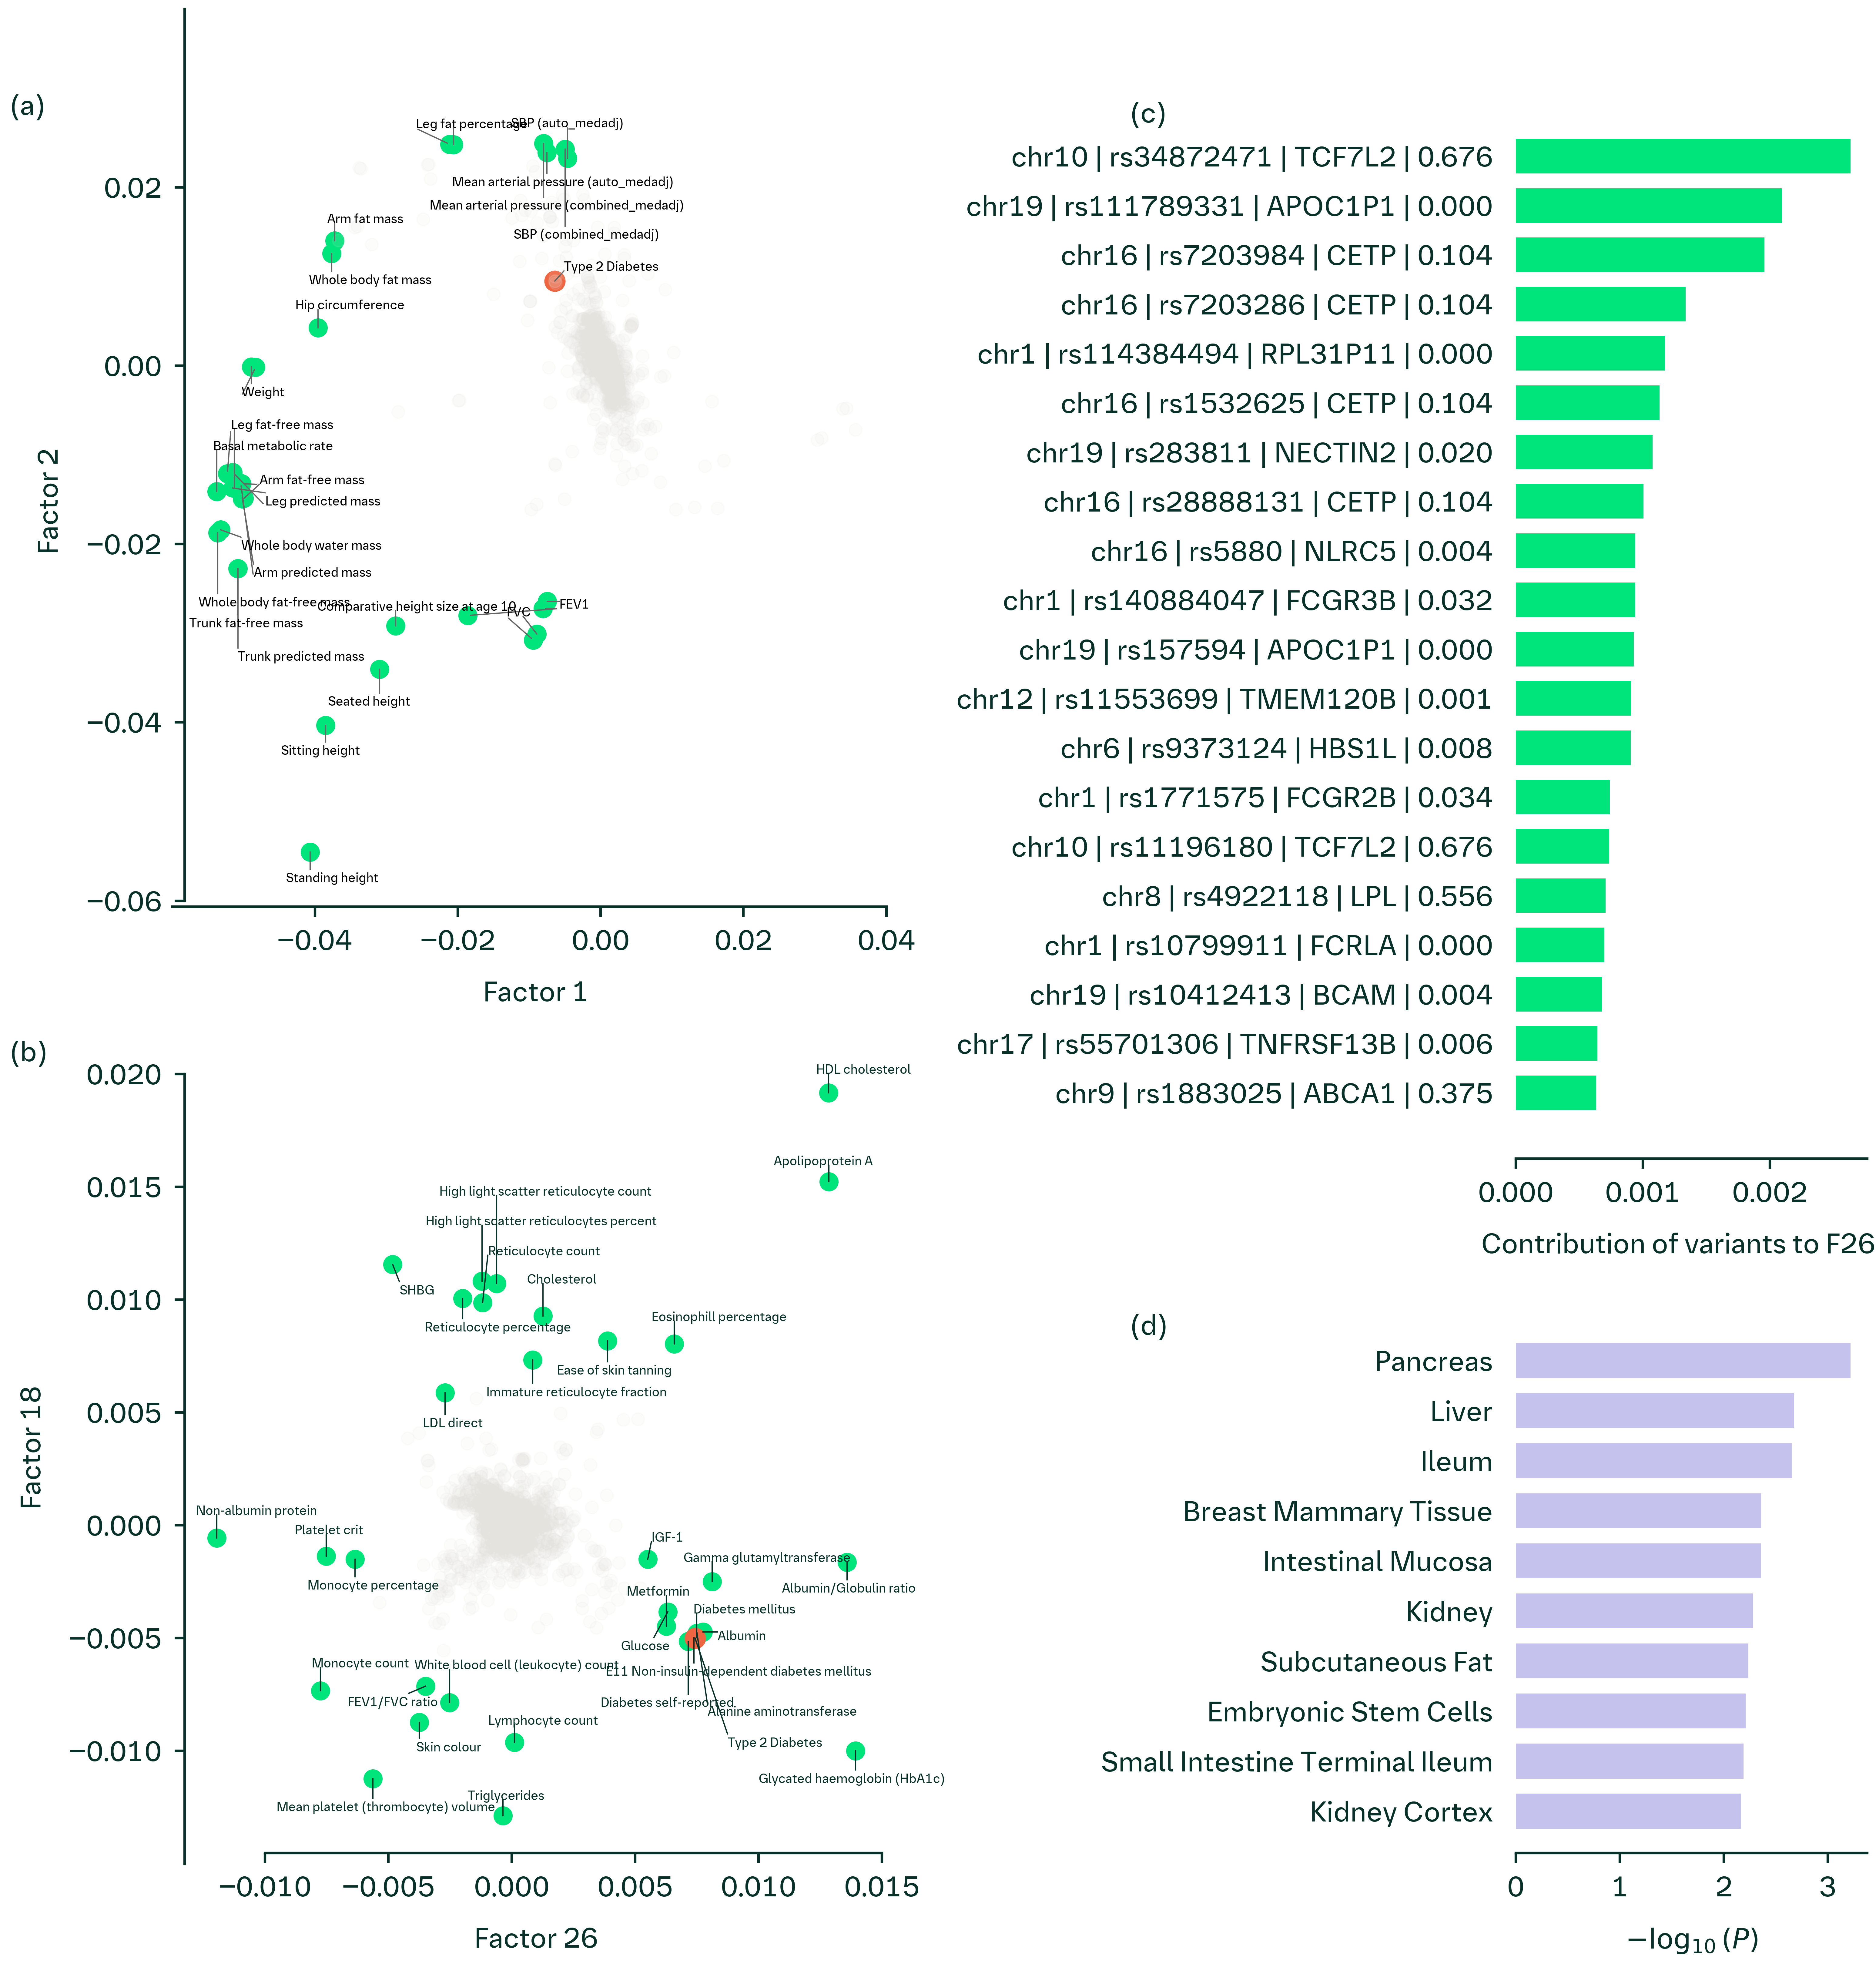

In [34]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize = (22, 22))
# fig = plt.figure(figsize = (20, 20))

# plot_colors_trait_points_highlight = manuscript_colors['darkyellow']
# plot_colors_trait_points_focal = manuscript_colors['purple']
# plot_colors_trait_points = manuscript_colors['lightgray']
# plot_colors_text = 'black'
# plot_colors_text_lines = manuscript_colors['gray']
# plot_colors_bar_genes = manuscript_colors['darkred']
# plot_colors_bar_tissues = manuscript_colors['darkred']

plot_colors_trait_points_highlight = boehringer_colors['accentgreen']
plot_colors_trait_points_focal = boehringer_colors['mediumred']
plot_colors_trait_points = boehringer_colors['warmgray']
plot_colors_text = boehringer_colors['darkgreen']
plot_colors_text_lines = boehringer_colors['darkgreen']
plot_colors_bar_genes = boehringer_colors['accentgreen']
plot_colors_bar_tissues = boehringer_colors['violet']


gs = fig.add_gridspec(2, 2, height_ratios=(1, 1), width_ratios = (2,1), wspace=0, hspace=0)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[1,0])

gs_rcol = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0:2,1], height_ratios = (2, 1))
axr1 = fig.add_subplot(gs_rcol[0, 0])
axr2 = fig.add_subplot(gs_rcol[1, 0])

# PC1 vs PC2
factor_on_x = top_factor3
factor_on_y = top_factor1
xvals = - loadings[:, factor_on_x]
yvals = loadings[:, factor_on_y]

# Combine outliers in x-axis and y-axis
# outlier_idx_x = np.where(iqr_outlier(xvals, axis = 0, bar = 5.0))[0]
# outlier_idx_y = np.where(iqr_outlier(yvals, axis = 0, bar = 5.0))[0]
outlier_idx_x = np.argsort(contribution_pheno[:, factor_on_x])[::-1][:20]
outlier_idx_y = np.argsort(contribution_pheno[:, factor_on_y])[::-1][:15]
outlier_idx = np.union1d(outlier_idx_x, outlier_idx_y)
x_center = np.mean(ax1.get_xlim())
common_idx = np.setdiff1d(np.arange(xvals.shape[0]), outlier_idx)
txt_list = []
text_idx_list = []
for i in outlier_idx:
    if i != tidx:
        txt = trait_df_noRx.loc[trait_indices[i]]['short_description'].strip()
        txt_list.append(txt)
        text_idx_list.append(i)
# Mark Type 2 diabetes
txt_list.append("Type 2 Diabetes")
text_idx_list.append(tidx)

scatter_plot = ax1.scatter(xvals[outlier_idx], yvals[outlier_idx], 
                           alpha = 1.0, s = 200,
                           edgecolors = plot_colors_trait_points_highlight,
                           color = plot_colors_trait_points_highlight)
ax1.scatter(xvals[tidx], yvals[tidx], 
            s = 250, 
            edgecolors = plot_colors_trait_points_focal,
            color = plot_colors_trait_points_focal)
ax1.scatter(xvals[common_idx], yvals[common_idx], 
            alpha = 0.1, s = 100, color = plot_colors_trait_points)

# # Mark using textalloc package
# if len(text_idx_list) > 0:
#     txt_idx = np.array(text_idx_list)
#     textalloc.allocate_text(fig, ax1, xvals[txt_idx], yvals[txt_idx], txt_list,
#                             # x_scatter = xvals, y_scatter = yvals,
#                             scatter_plot = scatter_plot,
#                             textsize = 10, textcolor = 'black', 
#                             linecolor = manuscript_colors['gray'])
    
if len(text_idx_list) > 0:
    allocate_with_multi_arrows(
        fig, ax1,
        xvals, yvals,
        text_idx_list, txt_list,
        scatter_plot = scatter_plot,
        text_color = plot_colors_text,
        text_arrow_color = plot_colors_text_lines,
        textsize=10
    )

# # Mark using adjustText package
# # https://github.com/Phlya/adjustText
# annots = []
# for i, txt in zip(text_idx_list, txt_list):
#     if xvals[i] > x_center:
#         annots += [ax1.annotate(txt, (xvals[i], yvals[i]), fontsize = 6, ha = 'right')]
#     else:
#         annots += [ax1.annotate(txt, (xvals[i], yvals[i]), fontsize = 6)]
# adjust_text(annots, arrowprops=dict(arrowstyle='-', color = manuscript_colors['gray']))


# ax1.set_xticks([-0.010, -0.005, 0.0, 0.005, 0.010])
for side, border in ax1.spines.items():
    if side == 'left':
        border.set_bounds(-0.06, 0.04)
    elif side == 'bottom':
        border.set_bounds(-0.06, 0.04)
    else:
        border.set_visible(False)
ax1.set_xlabel(f"Factor {factor_on_x + 1}")
ax1.set_ylabel(f"Factor {factor_on_y + 1}")

# PC26 vs PC18 on ax2
factor_on_x = top_factor2
factor_on_y = top_factor4
xvals = loadings[:, factor_on_x]
yvals = - loadings[:, factor_on_y]

# Combine outliers in x-axis and y-axis
# outlier_idx_x = np.where(iqr_outlier(xvals, axis = 0, bar = 5.0))[0]
# outlier_idx_y = np.where(iqr_outlier(yvals, axis = 0, bar = 5.0))[0]
outlier_idx_x = np.argsort(contribution_pheno[:, factor_on_x])[::-1][:20]
outlier_idx_y = np.argsort(contribution_pheno[:, factor_on_y])[::-1][:20]
outlier_idx = np.union1d(outlier_idx_x, outlier_idx_y)
x_center = np.mean(ax2.get_xlim())
common_idx = np.setdiff1d(np.arange(xvals.shape[0]), outlier_idx)
txt_list = []
text_idx_list = []
for i in outlier_idx:
    if i != tidx:
        txt = trait_df_noRx.loc[trait_indices[i]]['short_description'].strip()
        txt_list.append(txt)
        text_idx_list.append(i)
# Mark Type 2 diabetes
txt_list.append("Type 2 Diabetes")
text_idx_list.append(tidx)

scatter_plot = ax2.scatter(xvals[outlier_idx], yvals[outlier_idx], 
                           alpha = 1.0, s = 200,
                           edgecolors = plot_colors_trait_points_highlight,
                           color = plot_colors_trait_points_highlight)
ax2.scatter(xvals[tidx], yvals[tidx], 
            s = 250, 
            edgecolors = plot_colors_trait_points_focal,
            color = plot_colors_trait_points_focal)
ax2.scatter(xvals[common_idx], yvals[common_idx], 
            alpha = 0.1, s = 100, color = plot_colors_trait_points)

#### Mark using textalloc package
if len(text_idx_list) > 0:
    txt_idx = np.array(text_idx_list)
    textalloc.allocate_text(fig, ax2, xvals[txt_idx], yvals[txt_idx], txt_list,
                            # x_scatter = xvals, y_scatter = yvals,
                            scatter_plot = scatter_plot,
                            textsize = 10, textcolor = plot_colors_text, 
                            linecolor = plot_colors_text_lines)

#### Mark using adjustText package
#### https://github.com/Phlya/adjustText
# annots = []
# for i, txt in zip(text_idx_list, txt_list):
#     if xvals[i] > x_center:
#         annots += [ax2.annotate(txt, (xvals[i], yvals[i]), fontsize = 6, ha = 'right')]
#     else:
#         annots += [ax2.annotate(txt, (xvals[i], yvals[i]), fontsize = 6)]
# adjust_text(annots, arrowprops=dict(arrowstyle='-', color = manuscript_colors['gray']))


# ax1.set_xticks([-0.010, -0.005, 0.0, 0.005, 0.010])
for side, border in ax2.spines.items():
    if side == 'left':
        border.set_bounds(-0.015, 0.02)
    elif side == 'bottom':
        border.set_bounds(-0.01, 0.015)
    else:
        border.set_visible(False)
ax2.set_xlabel(f"Factor {factor_on_x + 1}")
ax2.set_ylabel(f"Factor {factor_on_y + 1}")

# Contribution of variants
xvals = top_variant_score
yvals = np.arange(n_plot_variants)[::-1]

axr1.barh(yvals, xvals, 
          align = 'center', 
          height = 0.7, 
          color = plot_colors_bar_genes, 
          edgecolor = 'None')
axr1.set_yticks(yvals)
axr1.set_yticklabels(top_variant_names)

for side in ['top', 'right', 'left']:
    axr1.spines[side].set_visible(False)

axr1.tick_params(left=False)
axr1.set_xlabel(f"Contribution of variants to F{top_factor2 + 1}", horizontalalignment='left', x = -0.1)
axr1.set_xticks([0, 0.001, 0.002])
# ax1.set_title(method_names[method])

# Enrichment
xvals = -np.log10(cts_df["Coefficient_P_value"].to_numpy())
yvals = np.arange(n_plot_tissues)[::-1]

axr2.barh(yvals, xvals, 
          align = 'center', 
          height = 0.7, 
          color = plot_colors_bar_tissues, 
          edgecolor = 'None')
axr2.set_yticks(yvals)
axr2.set_yticklabels(cts_df["Name"])

for side in ['top', 'right', 'left']:
    axr2.spines[side].set_visible(False)

axr2.tick_params(left=False)
axr2.set_xlabel(r"$-\log_{10}(P)$")

# Panel labels
ax1.text(-0.25, 0.97, "(a)", transform=ax1.transAxes, fontweight='bold')
ax2.text(-0.25, 0.97, "(b)", transform=ax2.transAxes, fontweight='bold')
axr1.text(-1.10, 0.97, "(c)", transform=axr1.transAxes, fontweight='bold')
axr2.text(-1.10, 0.97, "(d)", transform=axr2.transAxes, fontweight='bold')

# gs.tight_layout(fig)
# plt.savefig('../plots/colormann-manuscript/clorinn_panukb_t2d.pdf', bbox_inches='tight')
# plt.show()

gs.tight_layout(fig)
plt.savefig('../plots/bi-2026/clorinn_panukb_t2d.png', transparent = True, bbox_inches='tight')
plt.show()

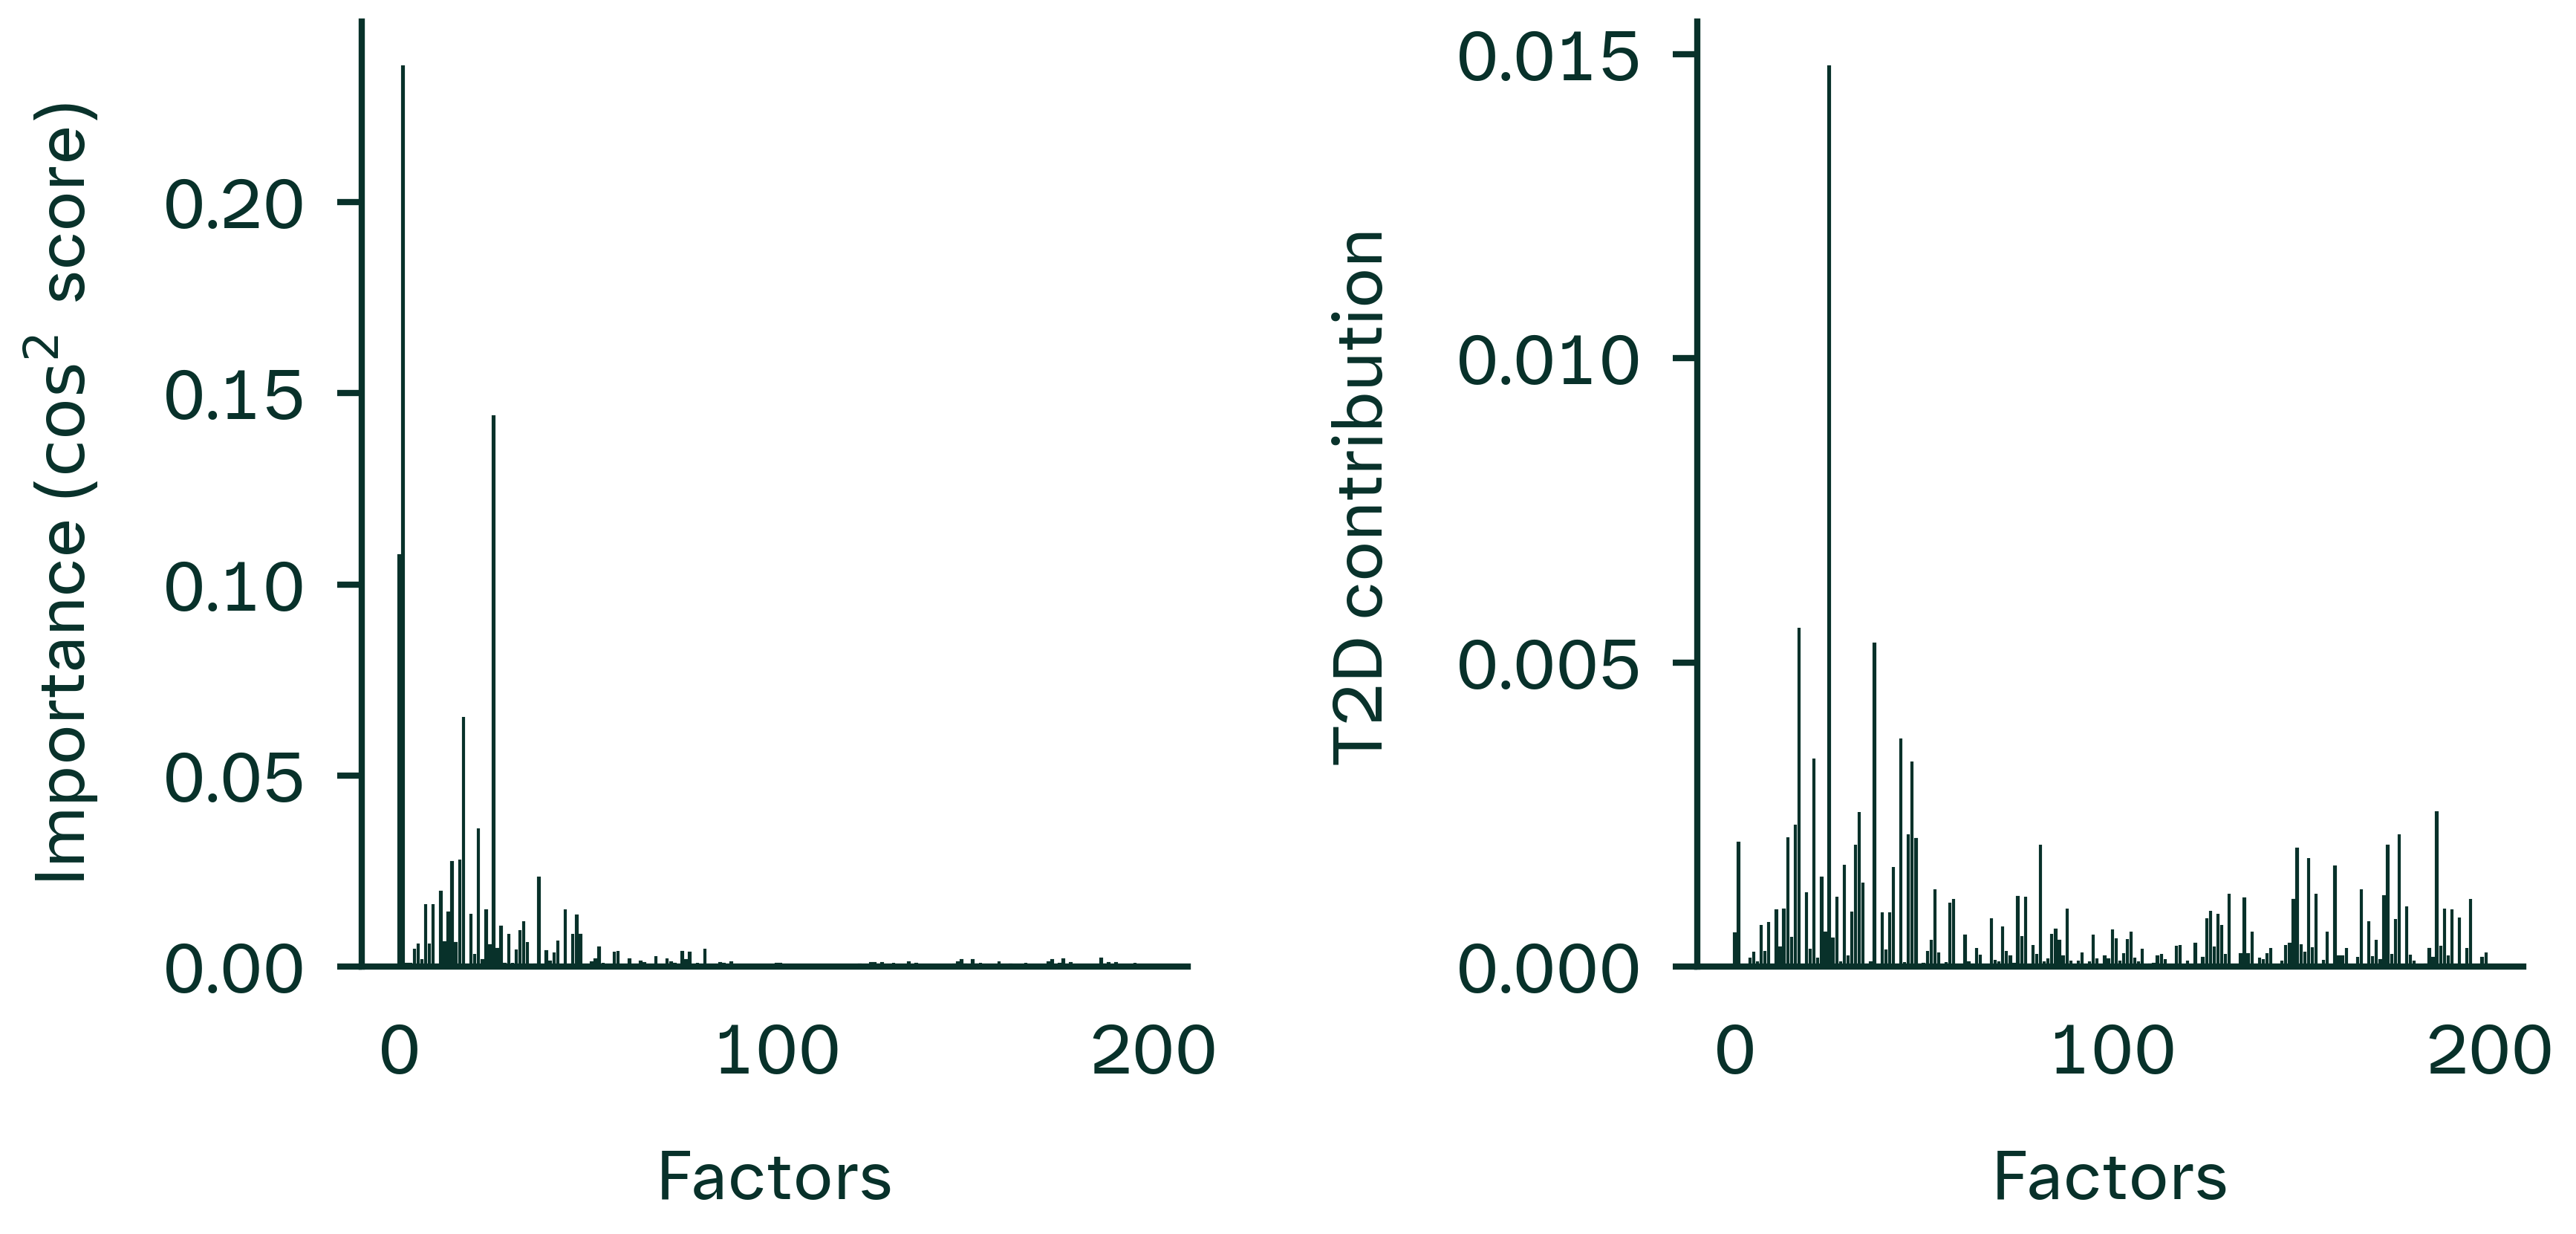

In [33]:
fig = plt.figure(figsize = (12, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

xvals = np.arange(cos2_pheno[tidx,:].shape[0])
yvals = cos2_pheno[tidx,:]
ax1.bar(xvals, yvals, align = 'center', width = 0.1)

xvals = np.arange(contribution_pheno[tidx, :].shape[0])
yvals = contribution_pheno[tidx, :]
ax2.bar(xvals, yvals, align = 'center', width = 0.05)

for side in ['top', 'right']:
    ax1.spines[side].set_visible(False)
    ax2.spines[side].set_visible(False)
    
ax1.tick_params(bottom=False)
ax1.set_ylabel(f"Importance ($\cos^2$ score)")
ax1.set_xlabel(f"Factors")

ax2.tick_params(bottom=False)
ax2.set_ylabel(f"T2D contribution")
ax2.set_xlabel(f"Factors")

# plt.tight_layout()
# plt.savefig('../plots/colormann-manuscript/panukb_t2d_cos2_contr.pdf', bbox_inches='tight')
# plt.show()

plt.tight_layout()
plt.savefig('../plots/bi-2026/panukb_t2d_cos2_contr.png', transparent = True, bbox_inches='tight')
plt.show()

In [35]:
contribution_pheno[tidx, 25]

0.01480045156111938